In [1]:
import matplotlib.pyplot as plt
import numpy as np

from superfv.finite_volume_driver import interpolate_cell_centers
from superfv.bin._finite_volume_driver import (
    interpolate_cell_centers as interpolate_cell_centers_cpp,
)

In [2]:
N = 32
ng = 2
p = 2

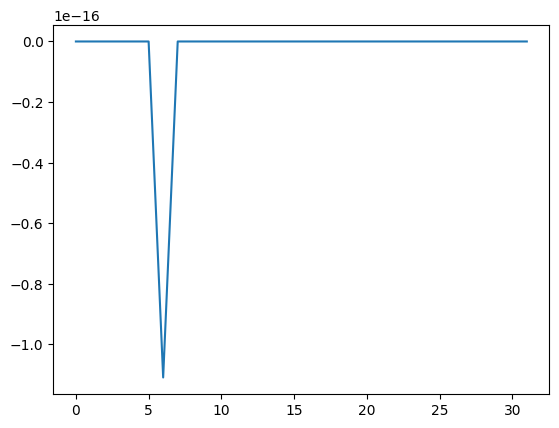

In [3]:
_N_ = N + 2 * ng
_q_ = np.ones((5, _N_, 1, 1))
_q_[:, _N_ // 4 : 3 * _N_ // 4, 0, 0] = 2.0

_qcc1_ = np.empty_like(_q_)
_qcc2_ = np.empty_like(_q_)

interpolate_cell_centers(_q_, _qcc1_, ("x",), p)
interpolate_cell_centers_cpp(_q_, _qcc2_, p, ng)

plt.plot(_qcc2_[0, ng:-ng, 0, 0] - _qcc1_[0, ng:-ng, 0, 0])

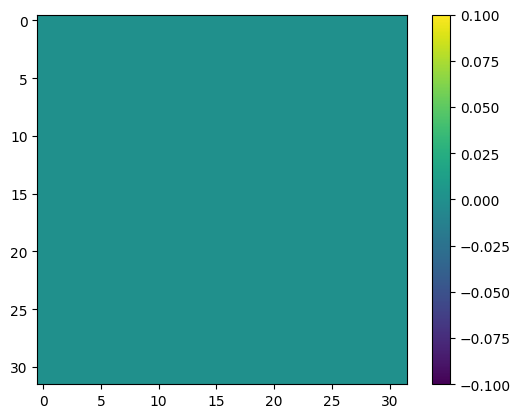

In [4]:
_N_ = N + 2 * ng
_q_ = np.ones((5, _N_, _N_, 1))
_q_[:, _N_ // 4 : 3 * _N_ // 4, _N_ // 4 : 3 * _N_ // 4, 0] = 2.0

_qcc1_ = np.empty_like(_q_)
_qcc2_ = np.empty_like(_q_)

interpolate_cell_centers(_q_, _qcc1_, ("x", "y"), p)
interpolate_cell_centers_cpp(_q_, _qcc2_, p, ng)

plt.imshow(_qcc2_[0, ng:-ng, ng:-ng, 0] - _qcc1_[0, ng:-ng, ng:-ng, 0])
plt.colorbar()

In [5]:
_N_ = N + 2 * ng
_q_ = np.ones((5, _N_, _N_, _N_))
_q_[:, _N_ // 4 : 3 * _N_ // 4, _N_ // 4 : 3 * _N_ // 4, _N_ // 4 : 3 * _N_ // 4] = 2.0

_qcc1_ = np.empty_like(_q_)
_qcc2_ = np.empty_like(_q_)

In [6]:
%%timeit
interpolate_cell_centers(_q_, _qcc1_, ("x", "y", "z"), p)

3.56 ms ± 459 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [7]:
%%timeit
interpolate_cell_centers_cpp(_q_, _qcc2_, p, ng)

3.31 ms ± 818 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


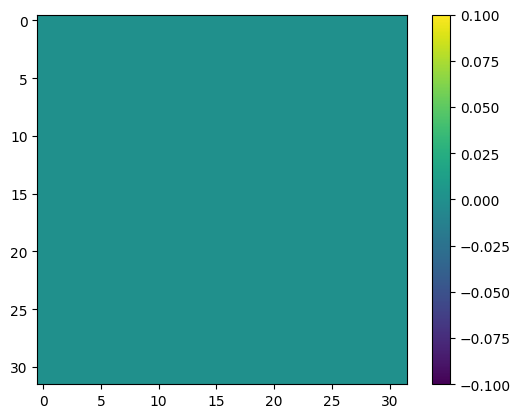

In [8]:
plt.imshow((_qcc2_ - _qcc1_)[0, ng:-ng, ng:-ng, _N_ // 2])
plt.colorbar()